# Modules

In [42]:
import sys
sys.path.insert(1, "../module")
import numpy as np      
import snflics
from skimage.transform import resize
from netCDF4 import Dataset                             
from scipy.ndimage import zoom
from matplotlib.patches import Rectangle                
import cartopy.crs as ccrs                              
import cartopy.feature as cfeature                   
import matplotlib.pyplot as plt                         
plt.style.use('default')                               
plt.rcParams['figure.facecolor'] = 'white'
import warnings
warnings.filterwarnings("ignore")
import cartopy.io.shapereader as shpreader

In [43]:
geodata = Dataset("/gws/ssde/j25b/swift/rt_cores/geoloc_grids/nxny2268_2080_nxnyds164580_blobdx0.04491576_arean41_n27_27_79.nc")
lons = geodata["lons_mid"][:]
lats = geodata["lats_mid"][:]

In [44]:
# replace missing values
filtered_lons = np.where(lons == -999.999, np.nan, lons)
filtered_lats = np.where(lats == -999.999, np.nan, lats)

In [45]:
lons.shape

(2079, 2263)

# Core data 

In [46]:
year = "2025"
month = "07"
day = "15"
hour = "12"
minute = "00"

In [47]:
path_core = f"/gws/ssde/j25b/swift/rt_cores/{year}/{month}/{day}/{hour}{minute}"
file = f"{path_core}/Convective_struct_extended_{year}{month}{day}{hour}{minute}_000.nc"

In [48]:
data = Dataset(file, mode='r')

# wavelet power maxima's coordinates
x0_lat = data["Pmax_lat"][:]
x0_lon = data["Pmax_lon"][:]

# wavelet power arrays
cores  = data["cores"][:, :]

In [49]:
# cloud top temperature and wavelet power arrays
binary_cores = (cores != 0).astype(int)

In [50]:
# Earth radius in km
R = 6371.0

def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.deg2rad, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# choose a representative point near the centre
i = lats.shape[0] // 2
j = lats.shape[1] // 2

# meridional spacing (north–south)
dy = haversine(
    lats[i, j], lons[i, j],
    lats[i+1, j], lons[i+1, j]
)

# zonal spacing (east–west)
dx = haversine(
    lats[i, j], lons[i, j],
    lats[i, j+1], lons[i, j+1]
)

print(f"dy (N–S spacing): {dy:.2f} km")
print(f"dx (E–W spacing): {dx:.2f} km")


dy (N–S spacing): 3.05 km
dx (E–W spacing): 3.09 km


# Plot Dakar Context Domain with Core Data

In [51]:
cores.shape

(2079, 2263)

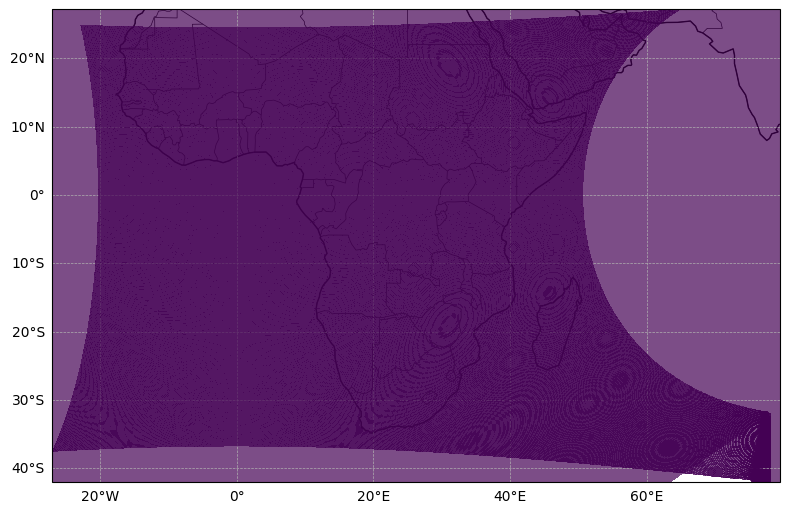

In [52]:
# Create figure and axis
fig = plt.figure(figsize=(8, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

extent = (
    np.nanmin(filtered_lons),
    np.nanmax(filtered_lons),
    np.nanmin(filtered_lats),
    np.nanmax(filtered_lats),    
)

ax.set_extent(extent, crs=ccrs.PlateCarree())


# Base features
ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='black', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='none', zorder=0)
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.5, zorder=1)

# Load Natural Earth country boundaries
shapename = 'admin_0_countries'
countries_shp = shpreader.natural_earth(resolution='10m', category='cultural', name=shapename)

# Gridlines
gl = ax.gridlines(draw_labels=True, alpha=1, linestyle='--', linewidth=0.5)
gl.top_labels = False
gl.right_labels = False

contour_core = ax.pcolormesh(
    lons, lats, np.ones(lats.shape),
    transform=ccrs.PlateCarree(),
    alpha=0.7,
    zorder=2
)
plt.tight_layout()
plt.show()

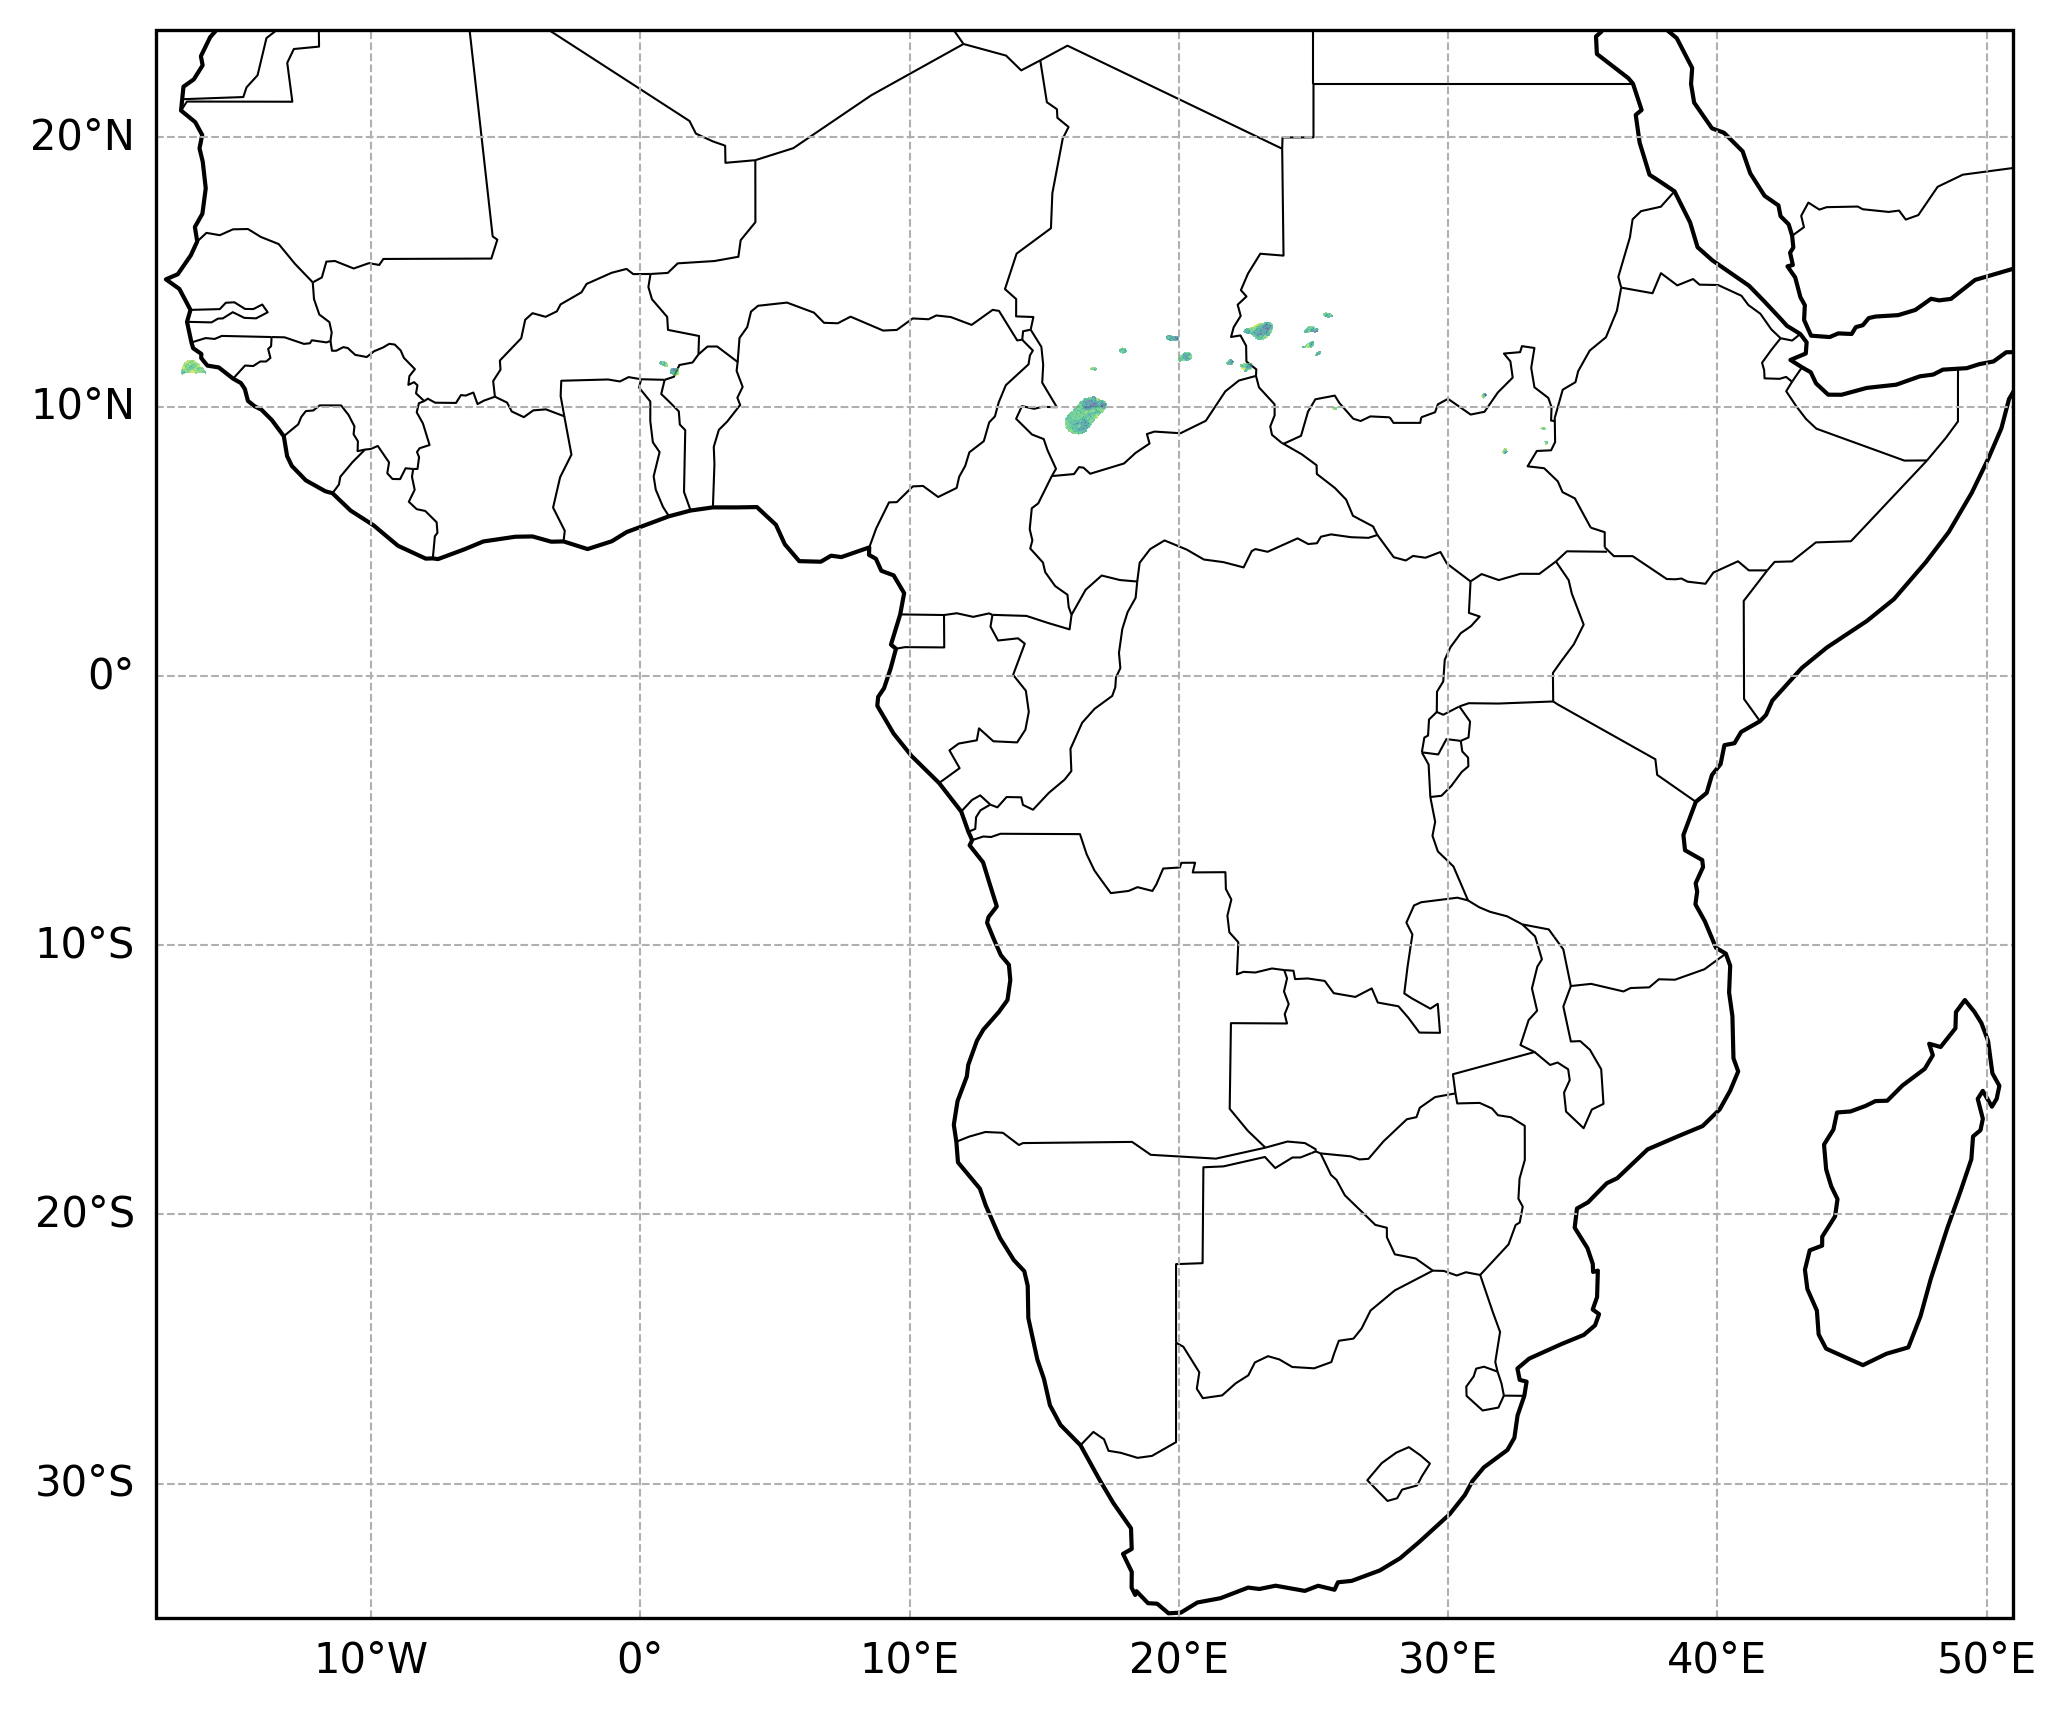

In [53]:
fig = plt.figure(figsize=(7, 10), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())

extent = (-18, 51, -35, 24)

ax.set_extent(extent, crs=ccrs.PlateCarree())

# Base features
ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='black', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='none', zorder=0)
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.5, zorder=1)

# Load Natural Earth country boundaries
shapename = 'admin_0_countries'
countries_shp = shpreader.natural_earth(resolution='10m', category='cultural', name=shapename)

# Gridlines
gl = ax.gridlines(draw_labels=True, alpha=1, linestyle='--', linewidth=0.5)
gl.top_labels = False
gl.right_labels = False

contour_core = ax.pcolormesh(
    lons, lats, cores,
    transform=ccrs.PlateCarree(),
    alpha=0.7,
    zorder=2
)
plt.tight_layout()
plt.show()

In [54]:
lats = np.where(lats == -999.999, np.nan, lats)
lons = np.where(lons == -999.999, np.nan, lons)

In [ ]:
LAT_MIN = -35
LAT_MAX = 24
LON_MIN = -18
LON_MAX = 51

# boolean mask selecting the desired region
mask = (
    (lats >= LAT_MIN) &
    (lats <= LAT_MAX) &
    (lons >= LON_MIN) &
    (lons <= LON_MAX)
)

# find bounding indices of mask
rows = np.where(mask.any(axis=1))[0]
cols = np.where(mask.any(axis=0))[0]

row_min, row_max = rows[0], rows[-1]
col_min, col_max = cols[0], cols[-1]

# crop arrays
core_crop = cores[row_min:row_max+1, col_min:col_max+1]
lats_crop   = lats[row_min:row_max+1, col_min:col_max+1]
lons_crop   = lons[row_min:row_max+1, col_min:col_max+1]

print(lons_crop.shape)


(2015, 2186)


In [56]:
print(row_min, row_max, col_min, col_max)

48 2062 77 2262


In [57]:
import torch